In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [2]:
# Load with relative path and specific encoding
df = pd.read_csv('spam.csv', encoding='ISO-8859-1')

# Inspect the data
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
# Drop columns that are empty or useless (errors='ignore' handles cases where they might not exist)
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], errors='ignore')

# Rename columns for clarity
df.columns = ['labels', 'text']
df.head()

,labels,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


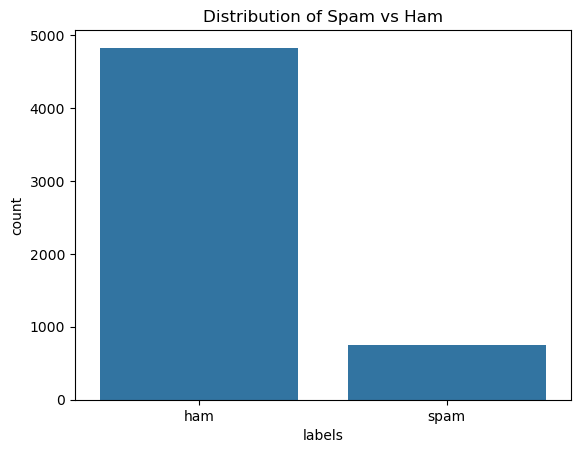

In [4]:
sns.countplot(x='labels', data=df)
plt.title('Distribution of Spam vs Ham')
plt.show()
# Observation: Usually, the dataset is imbalanced with significantly more 'ham' than 'spam'.

In [5]:
y = df['labels'].map({'ham': 0, 'spam': 1})

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], y, test_size=0.25, random_state=20, stratify=y
)
# Note: stratify=y ensures both sets have the same proportion of spam/ham as the original data.

In [38]:
# 1. Bag-of-Words (CountVectorizer)
bow_vect = CountVectorizer()
X_train_bow = bow_vect.fit_transform(X_train)
X_test_bow = bow_vect.transform(X_test)

# 2. TF-IDF (TfidfVectorizer)
tfidf_vect = TfidfVectorizer()
X_train_tfidf = tfidf_vect.fit_transform(X_train)
X_test_tfidf = tfidf_vect.transform(X_test)

print(f"BoW Matrix Shape: {X_train_bow.shape}")
print(f"TF-IDF Matrix Shape: {X_train_tfidf.shape}")

BoW Matrix Shape: (4179, 7422)
TF-IDF Matrix Shape: (4179, 7422)


In [39]:
# Function to train and evaluate
def evaluate_model(X_tr, X_te, y_tr, y_te):
    nb = MultinomialNB()
    nb.fit(X_tr, y_tr)
    preds = nb.predict(X_te)
    return accuracy_score(y_te, preds), f1_score(y_te, preds), preds

acc_bow, f1_bow, preds_bow = evaluate_model(X_train_bow, X_test_bow, y_train, y_test)
acc_tfidf, f1_tfidf, preds_tfidf = evaluate_model(X_train_tfidf, X_test_tfidf, y_train, y_test)

print(f"BoW -> Accuracy: {acc_bow:.4f}, F1: {f1_bow:.4f}")
print(f"TF-IDF -> Accuracy: {acc_tfidf:.4f}, F1: {f1_tfidf:.4f}")

BoW -> Accuracy: 0.9849, F1: 0.9425
TF-IDF -> Accuracy: 0.9512, F1: 0.7778


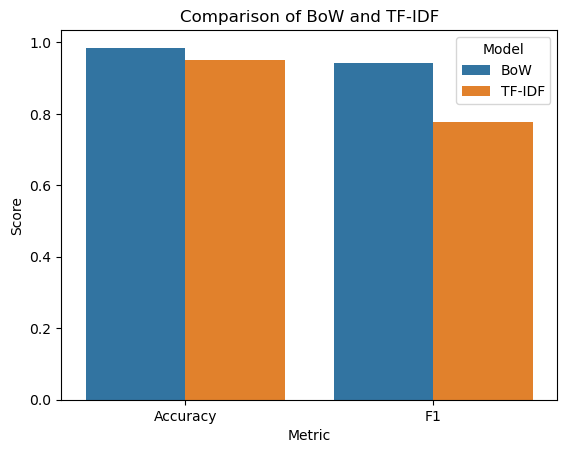

In [40]:
metrics_df = pd.DataFrame({
    'Model': ['BoW', 'TF-IDF', 'BoW', 'TF-IDF'],
    'Score': [acc_bow, acc_tfidf, f1_bow, f1_tfidf],
    'Metric': ['Accuracy', 'Accuracy', 'F1', 'F1']
})

sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_df)
plt.title('Comparison of BoW and TF-IDF')
plt.show()

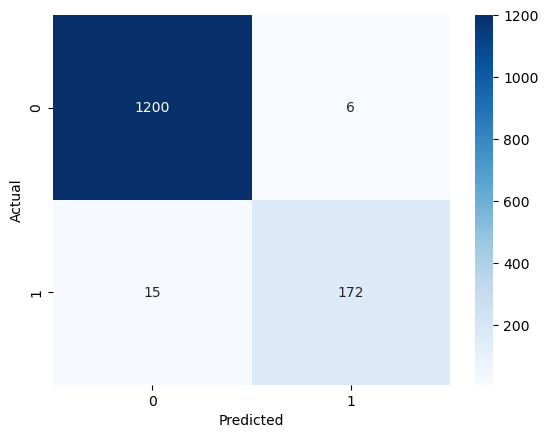

In [41]:
# Assuming BoW was the best
cm = confusion_matrix(y_test, preds_bow)
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [43]:
# 1. Create the Multinomial Naive Bayes model
nb_model_bow = MultinomialNB()

# 2. Fit (train) the model on the training set (BoW representation)
# This step is mandatory before calling .predict() [1]
nb_model_bow.fit(X_train_bow, y_train)

# 3. Now you can generate predictions (the line that previously failed)
y_pred_bow = nb_model_bow.predict(X_test_bow)

# 4. Compute metrics as required by Task 8 [1]
acc_bow = accuracy_score(y_test, y_pred_bow)
f1_bow = f1_score(y_test, y_pred_bow)

print(f"Accuracy: {acc_bow:.4f}, F1-score: {f1_bow:.4f}")

Accuracy: 0.9849, F1-score: 0.9425


In [45]:
# 1. Define your custom message
new_sms = ["Congratulations! You've won a $1000 Walmart gift card. Click here to claim now."]

# 2. Vectorize the message 
# IMPORTANT: Use .transform(), NOT .fit_transform(), to use the existing vocabulary [1]
new_sms_bow = bow_vect.transform(new_sms)

# 3. Predict using the trained BoW model [1]
prediction = nb_model_bow.predict(new_sms_bow)

# 4. Convert the numerical result back to a label
# We use the mapping from Task 5: {0: 'ham', 1: 'spam'} [3]
label = "SPAM" if prediction == 1 else "HAM"

print(f"Message: {new_sms}")
print(f"Prediction: {label}")

Message: ["Congratulations! You've won a $1000 Walmart gift card. Click here to claim now."]
Prediction: SPAM
